
---
## TEAM MEMBERS
* Gomez Serrato Alejandro 
* Quinche Rodríguez Juan Pablo
* Quintero Díaz Juan Jóse 
---
# Part 1: Data Loading & Preprocessing


1. Load `student_data.csv`.
2. Perform basic Exploratory Data Analysis (EDA). Plot the distribution of `critical_temp`.
3. Check for missing values or extreme anomalies. Be very careful: remove data or if you impute it, justify strongly. 
5. Split this training data into your own local train/test sets (e.g., 80/20) so you can evaluate your models.
6. **Feature Scaling:** Apply appropriate scaling. *Hint: Think carefully about why scaling is absolutely strictly necessary for both Regularized Linear Models and Neural Networks.*

## 1.1) Data loading

In [1]:
import sys
import os
print(os.getcwd())
sys.path.append(os.getcwd())
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
# Add the parent directory of 'utils' to sys.path so Python knows where to look
from utils import data_visualization as dv 
from utils import train_functions as tr
# Use a function from the script
path = './data/student_data.csv'
df = pd.read_csv(path)
print("the size of the dataset is:", np.size(df))
df.head()
print("amount of columns:", df.columns.size)

c:\Users\alejo\Desktop\capstone_project
the size of the dataset is: 1462860
amount of columns: 86


## 1.2) EDA for cf


--- Statistical Summary of cfinal ---

Skewness: 0.8564850677436356
Kurtosis: -0.5362429567171461


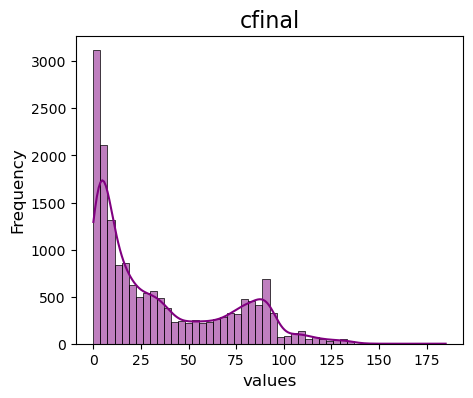

In [2]:
column = 'cfinal'
dv.eda_info(df[column],column)

## 1.3) Missing values  and data Cleaning

amount of null values in the dataset: 1288
null values per column:
eon       14
amm       10
mwma      12
amg       14
wagm      17
          ..
msqv      18
ril       18
ped       12
deu        8
cfinal    17
Length: 86, dtype: int64


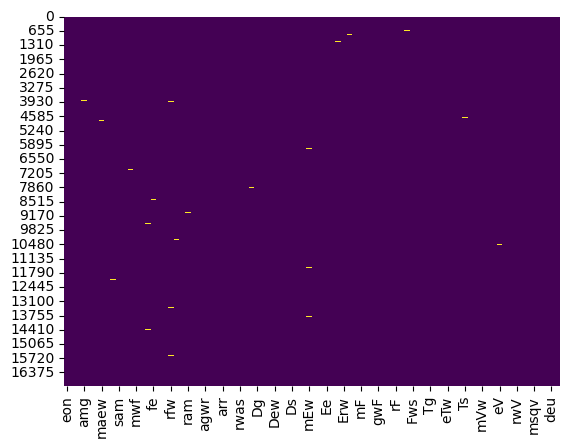

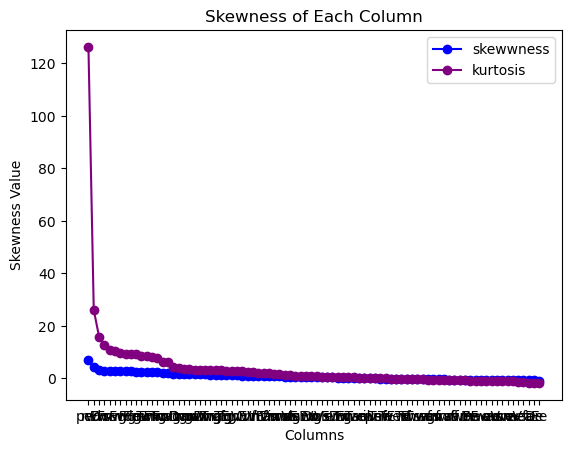

<Figure size 700x700 with 0 Axes>

In [3]:

print("amount of null values in the dataset:", df.isna().sum().sum())
print("null values per column:")
print(df.isna().sum(axis=0))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()
kurtosis = df.kurtosis(axis=0)
skewness = df.skew(axis=0)
sk_sort, ku_sort = tr.sort_values(skewness, kurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column']
colors = ['blue','purple']
labels = ['skewwness','kurtosis']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column']
dv.plot_values(sk_sort.index, [sk_sort.values,ku_sort.values], sk_text,labels_arr=labels,color_used=colors)
plt.figure(figsize=(7,7))
plt.show()
#dv.total_eda_info(df)
#tr.IQR_outliers(df)


Classifying with kurtosis and skewness 

In [4]:

meso_kt, lepto_kt, platy_kt = tr.classify_kurtosis(ku_sort,epsilon=0.1)
##Skewness classification
epsilon = 0.1
print("Meso-Kurtosis Columns skewness:")
left_sk_meso, middle_sk_meso, right_sk_meso = tr.classify_skewness(meso_kt, epsilon)
print(" ")
print("Lepto-Kurtosis Columns skewness:")
left_sk_lepto, middle_sk_lepto, right_sk_lepto = tr.classify_skewness(lepto_kt, epsilon)
print(" ")
print("Platy-Kurtosis Columns skewness:")
left_sk_platy, middle_sk_platy, right_sk_platy = tr.classify_skewness(platy_kt, epsilon)



Mesokurtic columns:
 5 columns
Leptokurtic columns:
 53 columns
Platykurtic columns:
 28 columns
Meso-Kurtosis Columns skewness:
Left-skewed columns:
 5 columns
Right-skewed columns:
 5 columns
Approximately symmetric columns:
 5 columns
 
Lepto-Kurtosis Columns skewness:
Left-skewed columns:
 53 columns
Right-skewed columns:
 53 columns
Approximately symmetric columns:
 53 columns
 
Platy-Kurtosis Columns skewness:
Left-skewed columns:
 28 columns
Right-skewed columns:
 28 columns
Approximately symmetric columns:
 28 columns


In [5]:
print("Meso-Kurtosis Columns:")
print(meso_kt)

Meso-Kurtosis Columns:
             0
eVw   0.065858
eF    0.036338
ril   0.008819
gwV  -0.054869
wear -0.094710


* platy_kurtosis(Mean or min/max) is left skewed wich means we can use the median 
* lepto_kurtosis(Median) is Right skewed wich means we can use the median
* Meso_kurtosis(Mean) is symmetric wich means we can use the mean


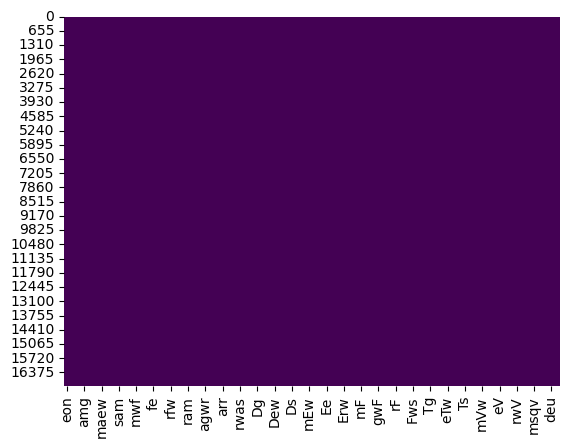

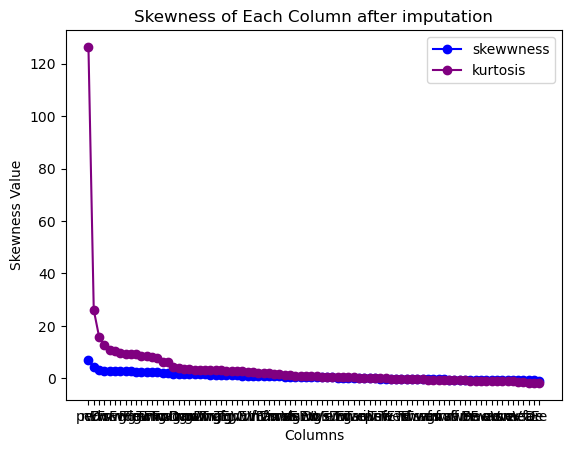

In [6]:
dvalues = df.copy()
dvalues = tr.median_imputation(dvalues, meso_kt.index)
dvalues = tr.median_imputation(dvalues, lepto_kt.index)
dvalues = tr.mean_imputation(dvalues, platy_kt.index)
dvalues.isna().sum()
sns.heatmap(dvalues.isnull(), cbar=False, cmap='viridis')
plt.show()
dkurtosis = dvalues.kurtosis(axis=0)
dskewness = dvalues.skew(axis=0)
dsk_sort, dku_sort = tr.sort_values(dskewness, dkurtosis)
colors = ['blue','purple']
labels = ['skewwness','kurtosis']
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column after imputation', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column after imputation', 'kurtosis']
dv.plot_values(dsk_sort.index, [dsk_sort.values,dku_sort.values], sk_text,labels_arr=labels,color_used=colors)
plt.show()


--- Statistical Summary of ped ---

Skewness: 6.852915400913597
Kurtosis: 126.38996414859876


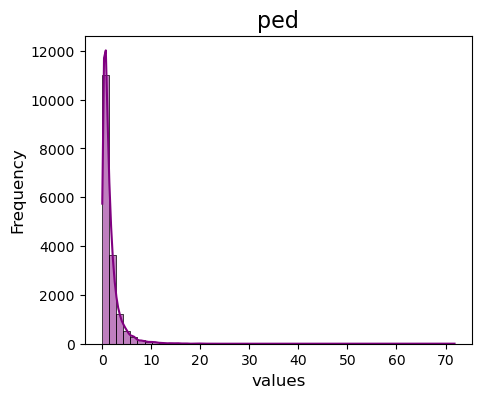

In [7]:
dv.eda_info(dvalues['ped'],"ped")
#dvalues.drop(columns=['ped'], inplace=True)

## 1.4)Train test split


After correlation filtering:
Features remaining: 81
Training set shape: (13608, 81)
Testing set shape:  (3402, 81)


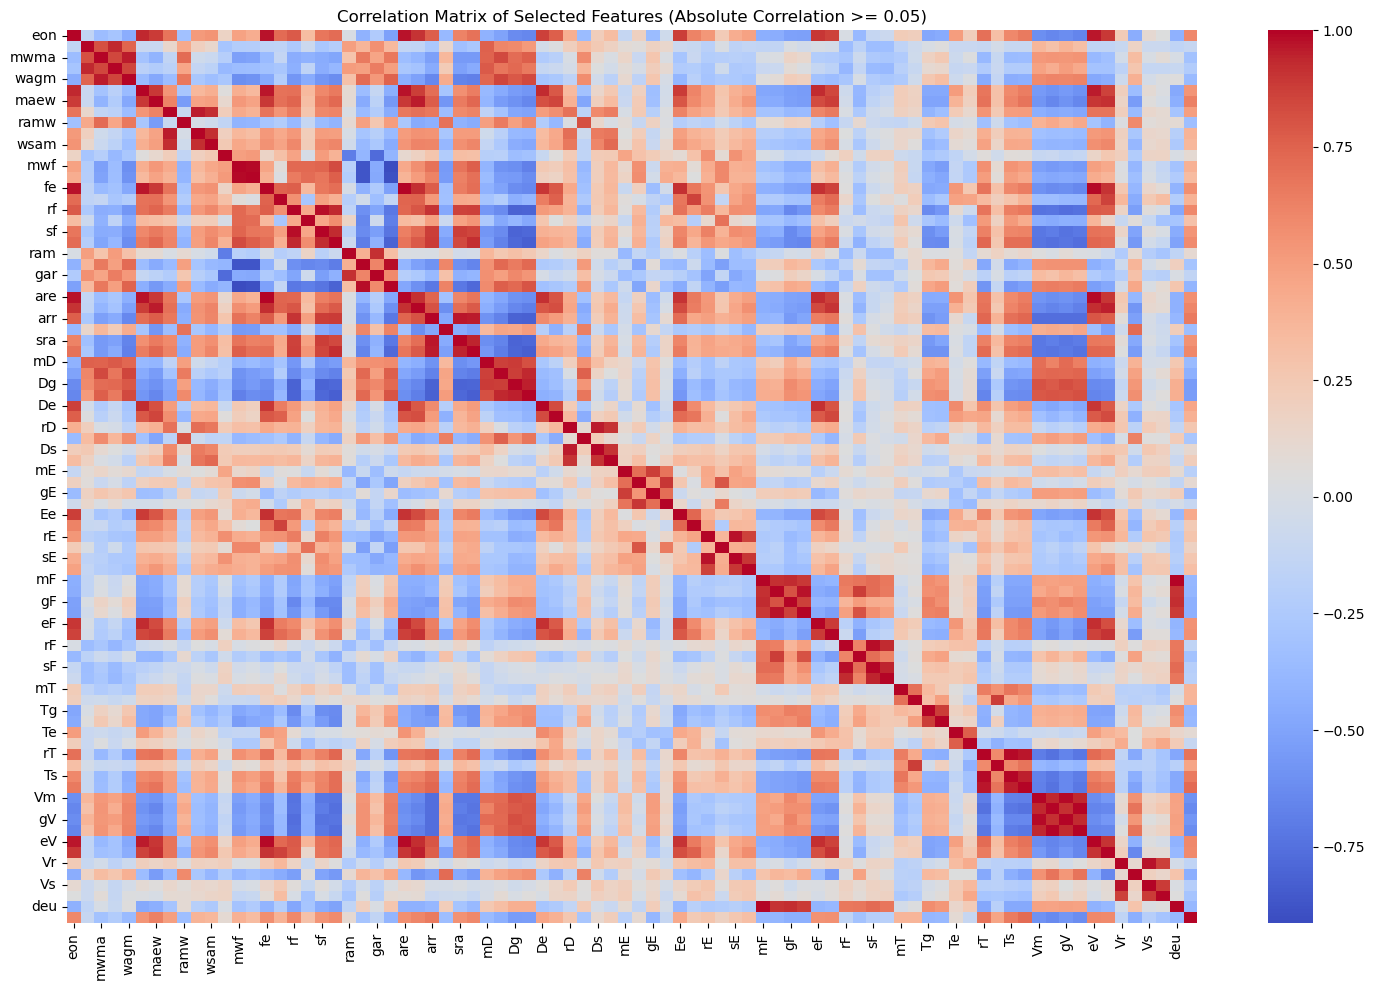

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#Alternative iterative imputation
#X_imputed,Y = tr.iterative_imputation(dvalues, 'cfinal')
#X_train,X_test,Y_train,Y_test = train_test_split(X_imputed,Y, test_size=0.2, random_state=42)

X = dvalues.drop('cfinal', axis=1)
Y = dvalues['cfinal']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Filtrado por correlación estricto (utilizando solo el Train Set)
X_train_filtered,X_test_filtered,features_to_use = tr.filter_colls_corr(dvalues,X_train,X_test,Y_train,threshold=0.05)


## 1.5) Scaling the features

In [9]:

X_train_scaled = tr.scale_data(X_train_filtered)
X_test_scaled = tr.scale_data(X_test_filtered)




# Part 2: Conceptual Questions & Model Selection

**Answer the following questions below:**
1. Why is this specific problem framed as a **Regression** task?
2. If a colleague suggested using **Logistic Regression** for this task, how would you explain to them mathematically and conceptually why that is the wrong choice?

Because we are trying to predict the behaviour of cfinal, wich we can consider as a continuous variable that depends on a linear combination of the other features.
Wich means that a linear regression model is appropriate for this task, as it can capture the linear relationships between the features and the target variable.
Furthermore cfinal is a normal distribution with kurtosis and skewness values close to 0, which indicates that it is a good candidate for linear regression.
2.Logistic regression is not suitable for this task because it is designed for classification problems, where the target variable is categorical. In contrast, linear regression is specifically designed for regression problems, where the target variable is continuous, making it the appropriate choice for predicting the final grade of the students.
In the case of the linear regression we have a continous set of values as.
\begin{equation*}
\hat{y} = \beta_{0} + \beta_{1}x_{1} +...+\beta_{n}x_{n}
\end{equation*}
 And in Logistic regression we use the sigmoid function wich maps the values between 0 and 1. 
\begin{equation*}
P(y=1|X) = \frac{1}{1+ e^{-( \beta_{0} + \beta_{1}x_{1} +...+\beta_{n}x_{n})}}
\end{equation*}

* When z is large and positive $e^{-z}$ approaches 0, so $\sigma{(z)}$ approaches 1.
* When z is large and negative  $e^{-z}$ becomes very large, so $\sigma{(z)}$ approaches 0.
* When z = 0, $e^0 = 1$, so $\sigma{(z)} = 0.5 $


# Part 3: Linear Regression & Regularization


## 1. Unregularized Linear Regression:
 Train a standard Ordinary Least Squares (OLS) Linear Regression model. Record its performance (RMSE, MAE, and $R^2$) on your local test set.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
from utils import test_functions as tf
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
print("--- 1. OLS Linear Regression ---")
u_model = LinearRegression()
u_model.fit(X_train_scaled, Y_train)
u_preds = u_model.predict(X_test_scaled)

# Cálculo de Métricas solicitadas
ols_rmse, ols_mae, ols_r2 = tf.evaluate_model(u_model, X_test_scaled, Y_test, "Unregularized Linear Regression")



--- 1. OLS Linear Regression ---
Unregularized Linear Regression RMSE: 17.781
Unregularized Linear Regression MAE:  13.596
Unregularized Linear Regression R^2:  0.730



## 2. Analyze the fullfilment of the linear regression model assumptions. 

Checking for Linearity (Visual Check)...


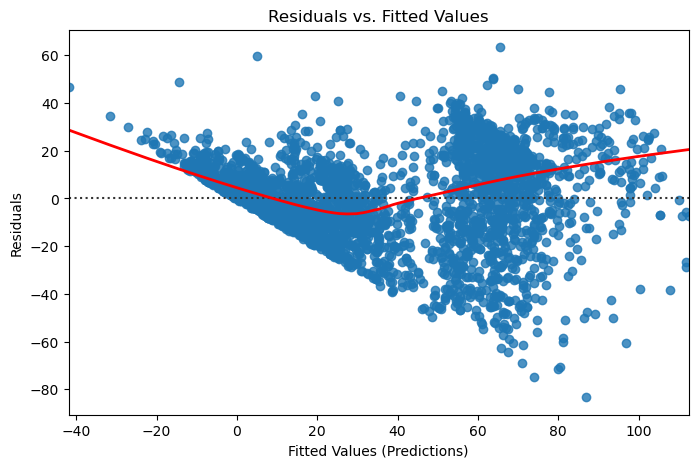

Checking for Independence of Residuals (Durbin-Watson Test)...
Durbin-Watson statistic: 1.95
Result: No significant autocorrelation (Good).


Checking for Homoscedasticity (Breusch-Pagan Test)...
Breusch-Pagan Test p-value: 0.0000
Result: Evidence of heteroscedasticity found (Bad).


Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...


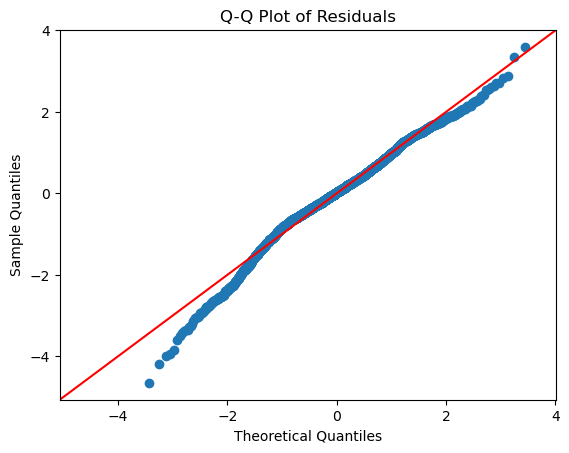

Jarque-Bera test probability (p-value): 0.0000
Result: Residuals may not be normally distributed (Bad).


Checking for Multicollinearity (VIF)...
    feature         VIF
0         0   49.476393
1         1  296.278365
2         2  680.439554
3         3  324.649018
4         4  763.350959
..      ...         ...
76       76   48.346425
77       77   23.589480
78       78   55.232353
79       79   18.368862
80       80  635.939312

[81 rows x 2 columns]

Result: Potential multicollinearity detected (Bad).




In [11]:
tf.tests_check(u_model, X_test_scaled, Y_test)

### 3. Regularization (Ridge & Lasso):
   * Train a Ridge (L2) and a Lasso (L1) regression model. 
   * Use $k$-fold cross-validation to find the optimal regularization hyperparameters ($\alpha$).

In [12]:

# Definimos una grilla logarítmica de alphas para buscar el óptimo
alphas_grid = np.logspace(-4, 4, 100)
# RidgeCV y LassoCV hacen la validación cruzada k-fold internamente
r_model = RidgeCV(alphas=alphas_grid, cv=5)
r_model.fit(X_train_scaled, Y_train)

l_model = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000) # max_iter alto para convergencia
l_model.fit(X_train_scaled, Y_train)

print(f"Optimal Ridge alpha: {r_model.alpha_:.4f}")
print(f"Optimal Lasso alpha: {l_model.alpha_:.4f}\n")

r_mse, r_mae, r_r2 = tf.evaluate_model(r_model, X_test_scaled, Y_test, "Ridge Regression")
l_mse, l_mae, l_r2 = tf.evaluate_model(l_model, X_test_scaled, Y_test, "Lasso Regression")
#tf.check_regularized_residuals(r_model, X_test_scaled, Y_test, "Ridge Regression")
#tf.check_regularized_residuals(l_model, X_test_scaled, Y_test, "Lasso Regression")


Optimal Ridge alpha: 1.3219
Optimal Lasso alpha: 0.0020

Ridge Regression RMSE: 17.760
Ridge Regression MAE:  13.603
Ridge Regression R^2:  0.731

Lasso Regression RMSE: 17.772
Lasso Regression MAE:  13.599
Lasso Regression R^2:  0.731



4. Reflection: Print the top 5 largest coefficients from your unregularized model and your Ridge model. How drastically did they change? 
5. **Feature Selection:** Did your Lasso model drop any features (set their coefficients to exactly zero)? Look specifically at `lattice_refraction_index` and `mean_quantum_spin_variance`. What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?


In [13]:

print("--- 4. Reflection: Coefficient Comparison ---")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_filtered.columns) # Convertir a DataFrame para obtener nombres de columnas
features = X_train_scaled_df.columns # Asegúrate de que X_train_scaled sea un DataFrame, si es numpy usa tus feature_names
models = {'u_model':u_model,'r_model':r_model,'l_model':l_model}
tf.top_coefficients(features,models)


--- 4. Reflection: Coefficient Comparison ---
Top 5 largest coefficients (Unregularized OLS):
   Feature   OLS_Coef
21    rwam  53.222773
23    agwr -48.756955
26     arr  31.251368
16      rf  29.148004
28     sra -28.357145
Top 5 largest coefficients (Ridge):
   Feature  Ridge_Coef
21    rwam   42.721351
23    agwr  -35.199835
26     arr   30.500761
28     sra  -28.788247
16      rf   28.224518
Top 5 largest coefficients (Lasso):
   Feature  Lasso_Coef
21    rwam   49.209186
23    agwr  -43.761706
26     arr   30.535781
16      rf   28.251764
28     sra  -27.760646
--- 5. Feature Selection (Lasso) ---
Lasso dropped 1 features.
-> eon se mantuvo con un coeficiente de -8.1474.
-> amm se mantuvo con un coeficiente de 9.7892.
-> mwma se mantuvo con un coeficiente de -7.4270.
-> amg se mantuvo con un coeficiente de -1.3050.
-> wagm se mantuvo con un coeficiente de 0.3284.
-> mea se mantuvo con un coeficiente de -11.5388.
-> maew se mantuvo con un coeficiente de 2.2336.
-> mra se mantuvo c

## 6. Include your best linear model weights in the submission using `joblib`

In [14]:


best_model = r_model
joblib.dump(best_model, 'best_linear_model.pkl')
print("\nModelo guardado exitosamente como 'best_linear_model.pkl'")




Modelo guardado exitosamente como 'best_linear_model.pkl'


## Models Testing

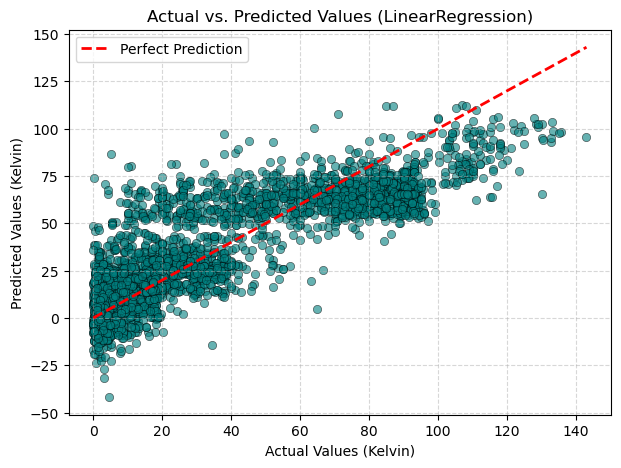

R² del modelo: 0.7305


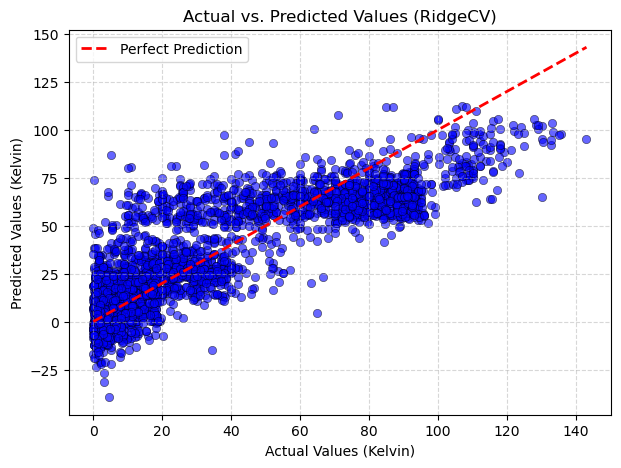

R² del modelo: 0.7311


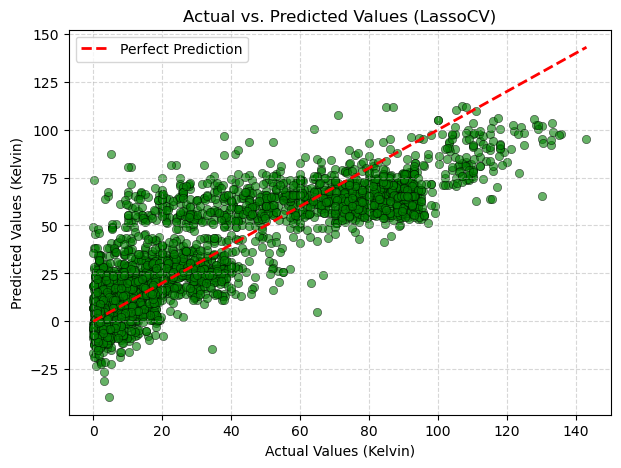

R² del modelo: 0.7307
--- RENDIMIENTO EN EL SPLIT LOCAL (80-20) ---


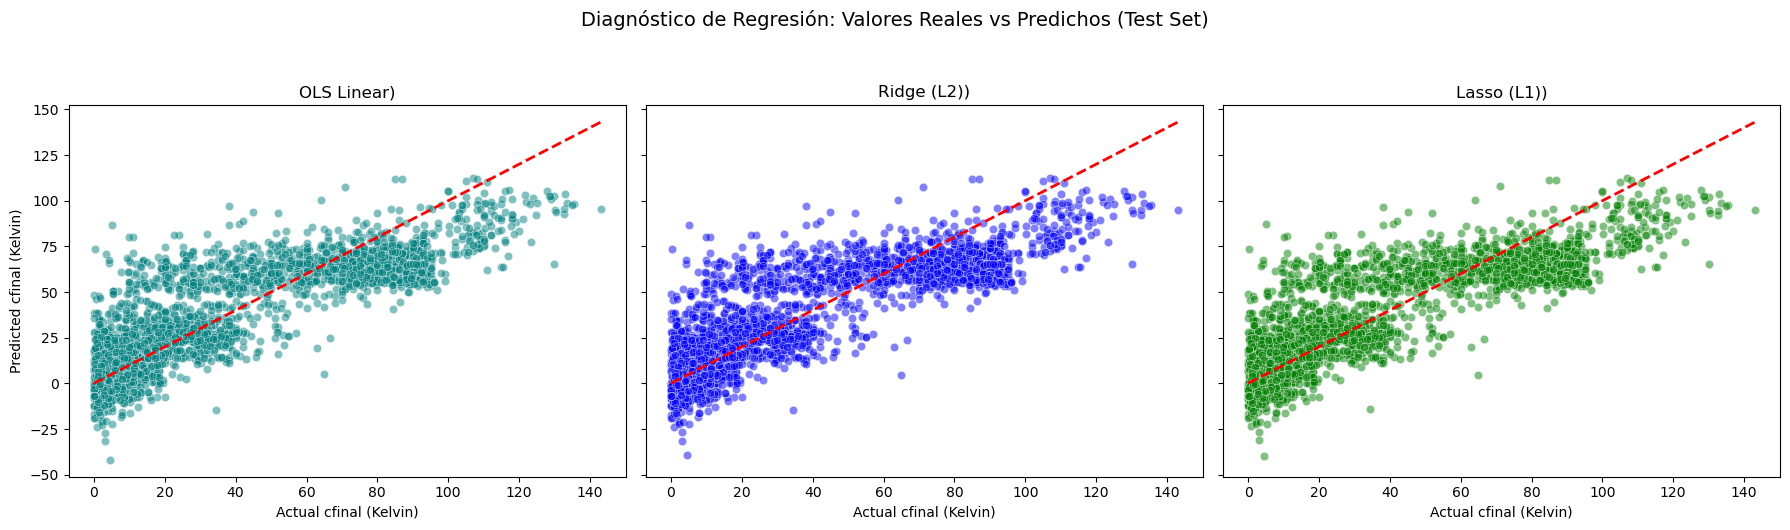

In [15]:
tf.simple_testing(u_model, X_test_scaled, Y_test, cu='teal')
tf.simple_testing(r_model, X_test_scaled, Y_test, cu='blue')
tf.simple_testing(l_model, X_test_scaled, Y_test, cu='green')
models = {'OLS Linear': u_model, 'Ridge (L2)': r_model, 'Lasso (L1)': l_model}
dv.multiple_model_diagnostics(models, X_test_scaled, Y_test)


--- Procesando archivo de evaluación real ---


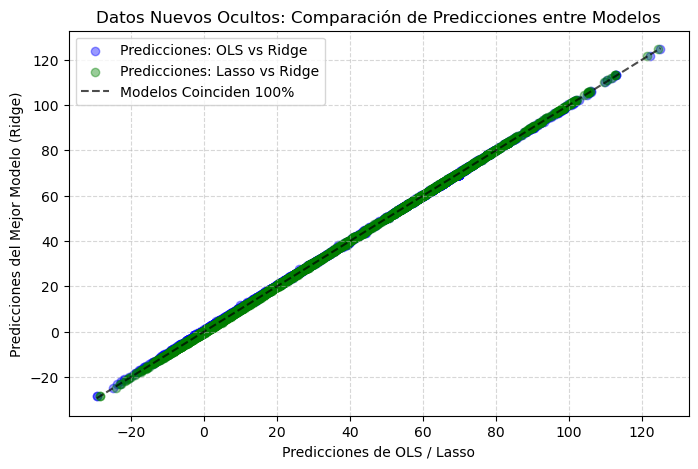

In [16]:
print("\n--- Procesando archivo de evaluación real ---")
eval_df = pd.read_csv('./data/evaluation_features.csv')
# Filtramos y escalamos usando estrictamente la misma estructura

X_eval_filtered = eval_df[features_to_use]
X_eval_scaled = tr.scale_data(X_eval_filtered) # ¡Aquí ya no habrá ValueError!
# Generamos las predicciones para los datos nuevos ocultos
eval_preds_ols = u_model.predict(X_eval_scaled)
eval_preds_ridge = r_model.predict(X_eval_scaled)
eval_preds_lasso = l_model.predict(X_eval_scaled)

# =====================================================================
# GRÁFICO 2: COMPARACIÓN DE PREDICCIONES EN LOS DATOS NUEVOS
# =====================================================================
# Como no conocemos el valor real, comparamos los modelos entre sí en los datos nuevos
plt.figure(figsize=(8, 5))
plt.scatter(eval_preds_ols, eval_preds_ridge, alpha=0.4, label='Predicciones: OLS vs Ridge', color='blue')
plt.scatter(eval_preds_lasso, eval_preds_ridge, alpha=0.4, label='Predicciones: Lasso vs Ridge', color='green')

# Línea de concordancia perfecta entre modelos
min_val = min(eval_preds_ridge.min(), eval_preds_ols.min())
max_val = max(eval_preds_ridge.max(), eval_preds_ols.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Modelos Coinciden 100%')

plt.title('Datos Nuevos Ocultos: Comparación de Predicciones entre Modelos')
plt.xlabel('Predicciones de OLS / Lasso')
plt.ylabel('Predicciones del Mejor Modelo (Ridge)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Part 4: Neural Networks

2. **Cross-Validation/Tuning:** Experiment with the architecture (number of hidden layers, neurons) and learning rate. Use a validation set to prevent overfitting (Early Stopping is highly recommended).
3. **Evaluation:** Evaluate your best Neural Network on your local test set using the same metrics as the linear models (RMSE, MAE, $R^2$). 
4. **Reflection:** Plot the residuals (predicted vs. true values) for both your best Linear model and your Neural Network. In what range does the linear model struggle the most compared to the NN?
5. **Include your best nn weights in the submission using `joblib`**. Describe the arquitecture.

## 1.)Build a Neural Network:
Implement a feedforward Neural Network (Multi-Layer Perceptron) using `sklearn`, `PyTorch`, or `Keras`.

In [17]:
data = [X_train_scaled, Y_train, X_test_scaled, Y_test]
default_nn,default_preds = tf.test_mlp_regressor(data)

Iteration 1, loss = 401.65563035
Validation score: 0.741159
Iteration 2, loss = 138.54649258
Validation score: 0.784664
Iteration 3, loss = 120.16488810
Validation score: 0.806892
Iteration 4, loss = 109.40462709
Validation score: 0.817154
Iteration 5, loss = 102.75512889
Validation score: 0.829931
Iteration 6, loss = 96.20769199
Validation score: 0.834394
Iteration 7, loss = 92.38927371
Validation score: 0.832675
Iteration 8, loss = 87.71084415
Validation score: 0.845603
Iteration 9, loss = 84.65136964
Validation score: 0.844854
Iteration 10, loss = 82.24837117
Validation score: 0.854866
Iteration 11, loss = 80.50516552
Validation score: 0.851267
Iteration 12, loss = 78.88753169
Validation score: 0.850504
Iteration 13, loss = 76.22070672
Validation score: 0.857607
Iteration 14, loss = 75.17579481
Validation score: 0.848928
Iteration 15, loss = 73.08315468
Validation score: 0.857977
Iteration 16, loss = 70.72790086
Validation score: 0.867116
Iteration 17, loss = 70.32286276
Validation 

Neural Network Regressor RMSE: 10.760
Neural Network Regressor MAE:  6.718
Neural Network Regressor R^2:  0.901



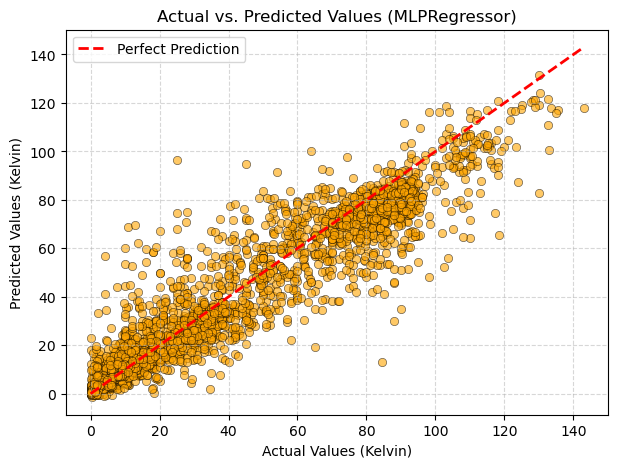

R² del modelo: 0.9013


In [18]:
tf.evaluate_model(default_nn, X_test_scaled, Y_test, "Neural Network Regressor")
tf.simple_testing(default_nn, X_test_scaled, Y_test, cu='orange')


# Part 5: Final Analysis and Exporting Predictions

**Final Analysis:**
Which model performed the best on your local test set? If a physicist asked you *which features* are most important for discovering a new material with this data, which model would you show them and why? Explain the trade-off between interpretability and performance in this context.

**Generate Final Predictions:**
Use your **best overall model** to predict the critical temperatures for the materials in `evaluation_features.csv`. Export your predictions to a CSV file named `my_predictions.csv`. It is just one column. Call it `predicted_cfinal`. 

In [24]:


eval_df=pd.read_csv('./data/evaluation_features.csv')
X_eval_filtered = eval_df[features_to_use]
X_eval_scaled = tr.scale_data(X_test_filtered)
#Predicciones
final_predictions = default_nn.predict(X_eval_scaled)
# Exportar a CSV con el nombre y columna requeridos
output_df = pd.DataFrame({'predicted_cfinal': final_predictions})
output_df.to_csv('./data/my_predictions.csv', index=False)

print(f"\nPredicciones exportadas a 'my_predictions.csv'")
print(f"Shape: {output_df.shape}")
print(f"\nEstadísticas de las predicciones:")
print(output_df['predicted_cfinal'].describe())


Predicciones exportadas a 'my_predictions.csv'
Shape: (3402, 1)

Estadísticas de las predicciones:
count    3402.000000
mean       33.290024
std        31.111398
min        -1.444322
25%         6.357490
50%        20.573432
75%        61.963049
max       131.726278
Name: predicted_cfinal, dtype: float64


# Bonus
If you first perform PCA, can you accomplish any dimensionality reduction? are your predictions better? analyze and support your claims.  


Visualization PCA - PC1: 28.78%, PC2: 22.40%, Total: 51.18%


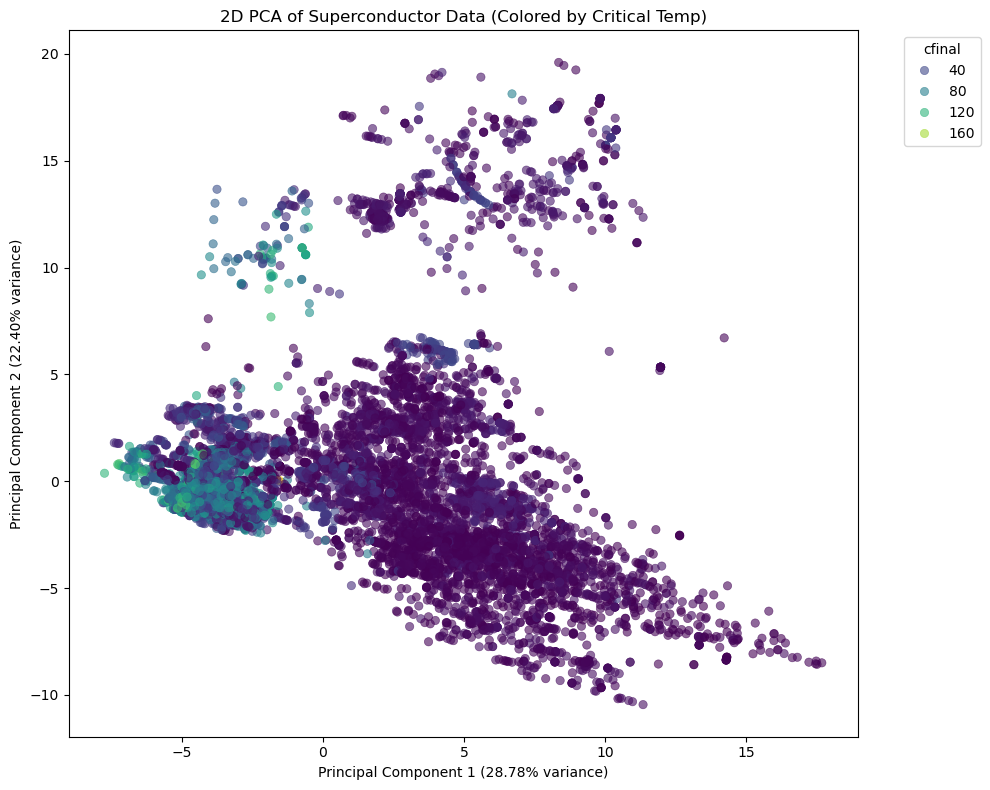


Modeling PCA - Components kept to explain 95% variance: 16


In [20]:
# ==========================================
# 3. PCA for Visualization (2 Components)
# ==========================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score



pca_vis = PCA(n_components=2)
X_train_pca_vis = pca_vis.fit_transform(X_train_scaled)

ev_vis = pca_vis.explained_variance_ratio_
print(f"\nVisualization PCA - PC1: {ev_vis[0]:.2%}, PC2: {ev_vis[1]:.2%}, Total: {ev_vis.sum():.2%}")

# Create DataFrame for plotting
pca_df = pd.DataFrame(X_train_pca_vis, columns=['PC1', 'PC2'])
pca_df['cfinal'] = Y_train.values

plt.figure(figsize=(10, 8))
# Using a scatterplot colored by the target variable (cfinal)
scatter = sns.scatterplot(
    x='PC1', y='PC2', 
    hue='cfinal', 
    palette='viridis', 
    data=pca_df, 
    alpha=0.6,
    edgecolor=None
)
plt.title('2D PCA of Superconductor Data (Colored by Critical Temp)')
plt.xlabel(f'Principal Component 1 ({ev_vis[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({ev_vis[1]:.2%} variance)')
# Move legend out of the way
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='cfinal')
plt.tight_layout()
plt.show()

# ==========================================
# 4. PCA for Predictive Modeling (95% Variance)
# ==========================================
# Instead of 2 components, let's let PCA pick the number of components 
# needed to explain 95% of the variance in the data.
pca_model = PCA(n_components=0.95)
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)

print(f"\nModeling PCA - Components kept to explain 95% variance: {pca_model.n_components_}")



In [21]:
# ==========================================
# 5. Testing Models on PCA Data (Bonus Question)
# ==========================================
alphas_grid = np.logspace(-4, 4, 100)
ridge_pca = RidgeCV(alphas=alphas_grid, cv=5)
ridge_pca.fit(X_train_pca, Y_train)

pca_preds = ridge_pca.predict(X_test_pca)

pca_rmse = np.sqrt(mean_squared_error(Y_test, pca_preds))
pca_r2 = r2_score(Y_test, pca_preds)

print(f"\n--- Ridge Regression on PCA Data ---")
print(f"Optimal Alpha: {ridge_pca.alpha_:.4f}")
print(f"RMSE: {pca_rmse:.3f}")
print(f"R^2:  {pca_r2:.3f}")


--- Ridge Regression on PCA Data ---
Optimal Alpha: 79.2483
RMSE: 21.623
R^2:  0.601


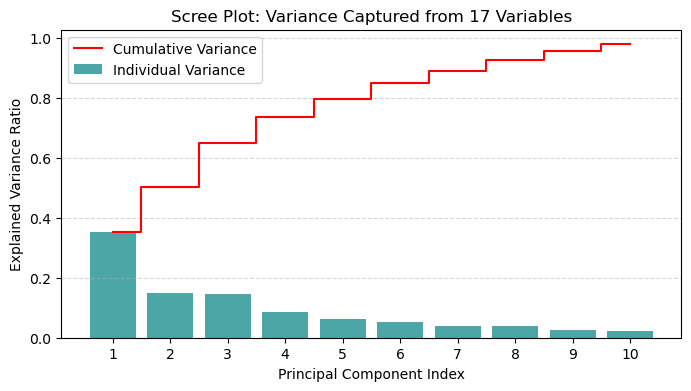

PC1 + PC2 capture: 50.29% of the total variance from the 17 features.


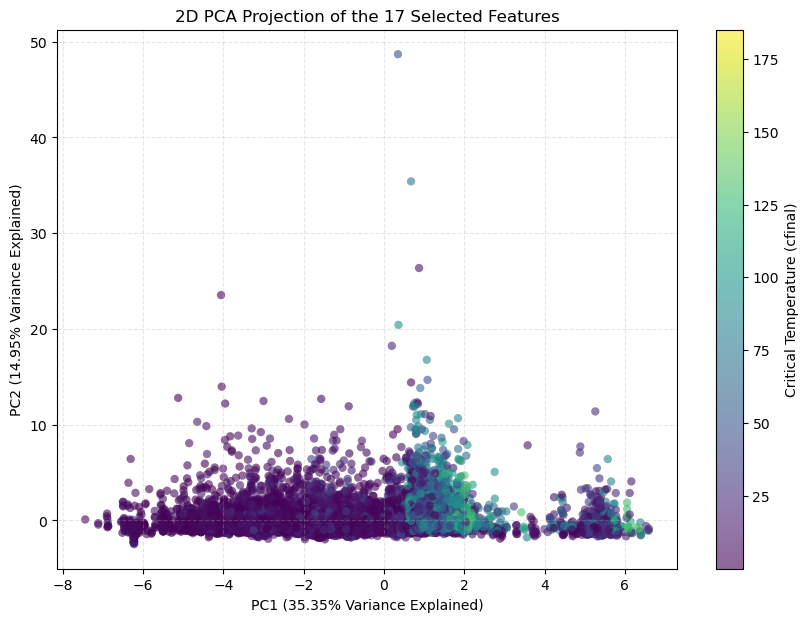

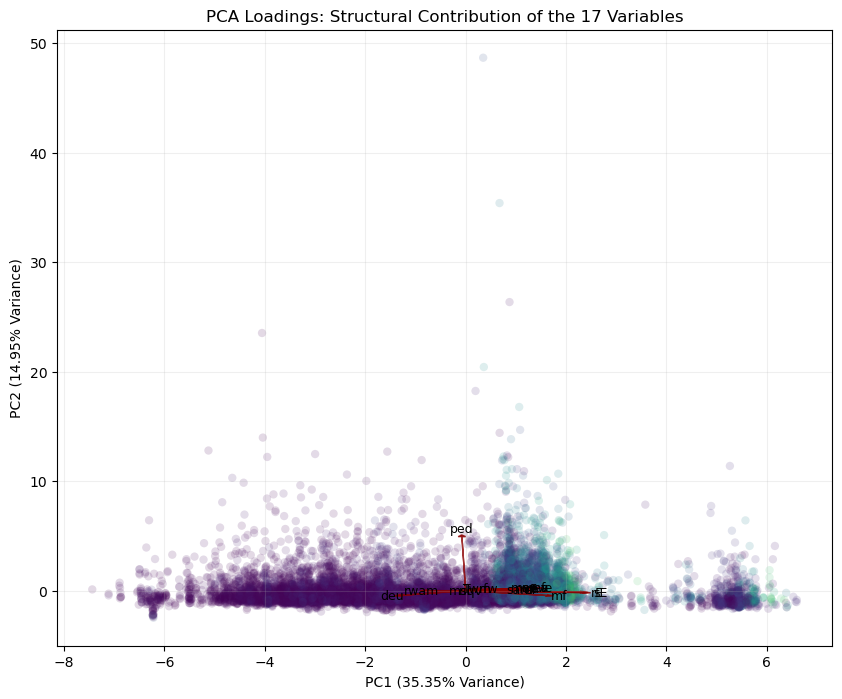

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

# --- Step 1: Isolate your 17 variables ---
# Replace this list with the exact names of your 17 features
my_17_features = [
    'sE', 'rwam', 'Twm', 'rf', 'rE', 'mea', 'maew', 'mra', 
    'sam', 'mf', 'fe', 'rfw', 'sf', 'msqv', 'ril', 'ped', 'deu'
]

# Extract features and target variable from your cleaned dataset
X_17 = dvalues[my_17_features]
Y = dvalues['cfinal']

# --- Step 2: Scale the 17 variables (Mandatory for PCA) ---
scaler_17 = RobustScaler()
X_17_scaled = scaler_17.fit_transform(X_17)

# --- Step 3: Run PCA ---
# We compute up to 10 components just to see the variance distribution
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_17_scaled)
evr = pca.explained_variance_ratio_

# =========================================================
# VISUALIZATION 1: Scree Plot (How much info did we keep?)
# =========================================================
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), evr, alpha=0.7, color='teal', label='Individual Variance')
plt.step(range(1, 11), np.cumsum(evr), where='mid', color='red', label='Cumulative Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot: Variance Captured from 17 Variables')
plt.xticks(range(1, 11))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"PC1 + PC2 capture: {(evr[0]+evr[1]):.2%} of the total variance from the 17 features.")

# =========================================================
# VISUALIZATION 2: 2D PCA Scatter Plot (Colored by Target)
# =========================================================
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['cfinal'] = Y.values

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_df['PC1'], pca_df['PC2'], 
    c=pca_df['cfinal'], cmap='viridis', alpha=0.6, edgecolors='none'
)
plt.colorbar(scatter, label='Critical Temperature (cfinal)')
plt.xlabel(f'PC1 ({evr[0]:.2%} Variance Explained)')
plt.ylabel(f'PC2 ({evr[1]:.2%} Variance Explained)')
plt.title('2D PCA Projection of the 17 Selected Features')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# =========================================================
# VISUALIZATION 3: PCA Biplot / Loading Plot 
# (Which of the 17 variables matter most to the components?)
# =========================================================
plt.figure(figsize=(10, 8))
# Plot the background data points lightly
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cfinal'], cmap='viridis', alpha=0.15, edgecolors='none')

# Extract loadings (coefficients mapping 17 features to PCs)
loadings = pca.components_

# Scale factor to stretch vectors so they are visible over the data coordinates
scaling_factor = 5.0 

for i, feature_name in enumerate(my_17_features):
    # Vector coordinates for the feature in PC space
    x_val = loadings[0, i] * scaling_factor
    y_val = loadings[1, i] * scaling_factor
    
    # Draw arrow
    plt.arrow(0, 0, x_val, y_val, color='darkred', alpha=0.8, head_width=0.15, head_length=0.15)
    # Label arrow
    plt.text(x_val * 1.15, y_val * 1.15, feature_name, color='black', ha='center', va='center', fontsize=9)

plt.xlabel(f'PC1 ({evr[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({evr[1]:.2%} Variance)')
plt.title('PCA Loadings: Structural Contribution of the 17 Variables')
plt.grid(True, alpha=0.2)
plt.show()

In [23]:
# ==========================================
# 5. Testing Models on PCA Data (Bonus Question)
# ==========================================
alphas_grid = np.logspace(-4, 4, 100)
r_pca = RidgeCV(alphas=alphas_grid, cv=5)
r_pca.fit(X_train_pca, Y_train)
r_pca_preds = r_pca.predict(X_test_pca)
pca_rmse = np.sqrt(mean_squared_error(Y_test, r_pca_preds))
pca_r2 = r2_score(Y_test, r_pca_preds)

l_pca = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000)
l_pca.fit(X_train_pca, Y_train)
l_pca_preds = l_pca.predict(X_test_pca)
l_pca_rmse = np.sqrt(mean_squared_error(Y_test, l_pca_preds))
l_pca_r2 = r2_score(Y_test, l_pca_preds)

print(f"\n--- Ridge Regression on PCA Data ---")
print(f"Optimal Alpha: {r_pca.alpha_:.4f}")
print(f"RMSE: {pca_rmse:.3f}")
print(f"R^2:  {pca_r2:.3f}")
print(f"\n--- Lasso Regression on PCA Data ---")
print(f"Optimal Alpha: {l_pca.alpha_:.4f}")
print(f"RMSE: {l_pca_rmse:.3f}")
print(f"R^2:  {l_pca_r2:.3f}")



--- Ridge Regression on PCA Data ---
Optimal Alpha: 79.2483
RMSE: 21.623
R^2:  0.601

--- Lasso Regression on PCA Data ---
Optimal Alpha: 0.0041
RMSE: 21.622
R^2:  0.601
